In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn import functional as F

from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


In [3]:
import random


class SinogramNoise:
    def __init__(self, mean=0.0, std=0.001, p=1.0):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, sample):
        sinogram, image = sample

        if random.random() < self.p:
            noise = torch.randn_like(sinogram) * self.std + self.mean
            sinogram = sinogram + noise
            sinogram.clamp_(0.0, 1.0)

        return sinogram, image

In [ ]:
from dival import get_standard_dataset

dataset = get_standard_dataset(
    "custom",
    data_path="../data/ct_ellipses_dataset",
    sinogram_shape=(256, 183),
    image_shape=(128, 128),
    parts_len={"train": 80, "validation": 10, "test": 10},
    impl="skimage",
)

transform = SinogramNoise(mean=0.0, std=0.0, p=1.0)

test_dataset = dataset.create_torch_dataset(part="train", transform=transform)

In [ ]:
batch_size = 4

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
)

In [6]:
from models.Pix2Pix_128 import UnetGenerator

In [ ]:
generator = UnetGenerator().to(device)

checkpoint = torch.load("../models/128x128_0601_pix2pix.pth", map_location=device)

generator.load_state_dict(checkpoint)

<All keys matched successfully>

In [8]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Number of trainable parameters:", count_parameters(generator))

Number of trainable parameters: 36894721


In [9]:
import math
import numpy as np


def calculate_psnr(img1, img2, max_val=1.0):
    img1_np = img1.squeeze().cpu().numpy()
    img2_np = img2.squeeze().cpu().numpy()
    mse = np.mean((img1_np - img2_np) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * math.log10(max_val) - 10 * math.log10(mse)


def calculate_mse(img1, img2):
    return F.mse_loss(img1, img2).item()


def calculate_ssim(img1, img2):
    img1_np = img1.squeeze().cpu().numpy()
    img2_np = img2.squeeze().cpu().numpy()
    ssim_value = ssim(img1_np, img2_np, data_range=img1_np.max() - img1_np.min())
    # Ensure we return only the scalar score.
    if isinstance(ssim_value, (tuple, list)):
        ssim_value = ssim_value[0]
    return float(ssim_value)

In [10]:
def hu_window(tensor, a=-200, b=200):
    # tensor in (0,1) representing HU [-1024, 3071]
    hu = tensor * (3071 + 1024) - 1024
    hu = torch.clamp(hu, a, b)
    hu = (hu - a) / (b - a)
    return hu

In [ ]:
from tqdm import tqdm

test_windowing = True
hu_windowing_min = -100
hu_windowing_max = 100

generator.eval()

mse_test = []
ssim_test = []
psnr_test = []
correlation_test = []

window_mse_test = 0.0
window_ssim_test = 0.0
window_psnr_test = 0.0
window_correlation_test = 0.0

with torch.no_grad():
    val_bar = tqdm(test_loader, desc=f"[Test]", leave=False)
    for sino, img in val_bar:
        sino = sino.unsqueeze(1).to(device, non_blocking=True)
        img = img.unsqueeze(1).to(device, non_blocking=True)

        output = generator(sino)

        mse_test.append(calculate_mse(img, output))
        ssim_test.append(calculate_ssim(img, output))
        psnr_test.append(calculate_psnr(img, output, max_val=1.0))
        correlation_test.append(
            np.corrcoef(
                img.squeeze().cpu().numpy().flatten(),
                output.squeeze().cpu().numpy().flatten(),
            )[0, 1]
        )

        if test_windowing:
            img_window = hu_window(img, a=hu_windowing_min, b=hu_windowing_max)
            window_output = hu_window(output, a=hu_windowing_min, b=hu_windowing_max)

            window_mse_test += calculate_mse(img_window, window_output)
            window_ssim_test += calculate_ssim(img_window, window_output)
            window_psnr_test += calculate_psnr(img_window, window_output, max_val=1.0)
            window_correlation_test += np.corrcoef(
                img_window.squeeze().cpu().numpy().flatten(),
                window_output.squeeze().cpu().numpy().flatten(),
            )[0, 1]

            window_mse_test /= len(test_loader)
            window_ssim_test /= len(test_loader)
            window_psnr_test /= len(test_loader)
            window_correlation_test /= len(test_loader)

print(
    f"Losses: "
    f"MSE: {(sum(mse_test) / len(mse_test)):.6f} | "
    f"SSIM: {(sum(ssim_test) / len(ssim_test)):.4f} | "
    f"PSNR: {(sum(psnr_test) / len(psnr_test)):.4f} | "
    f"Correlation: {(sum(correlation_test) / len(correlation_test)):.4f}"
)

if test_windowing:
    print(
        f"Windowed Losses: "
        f"MSE: {window_mse_test:.6f} | "
        f"SSIM: {window_ssim_test:.4f} | "
        f"PSNR: {window_psnr_test:.4f} | "
        f"Correlation: {window_correlation_test:.4f}"
    )

Losses: MSE: 0.000101 | SSIM: 0.9484 | PSNR: 40.7122 | Correlation: 0.9864
Windowed Losses: MSE: 0.002826 | SSIM: nan | PSNR: inf | Correlation: nan


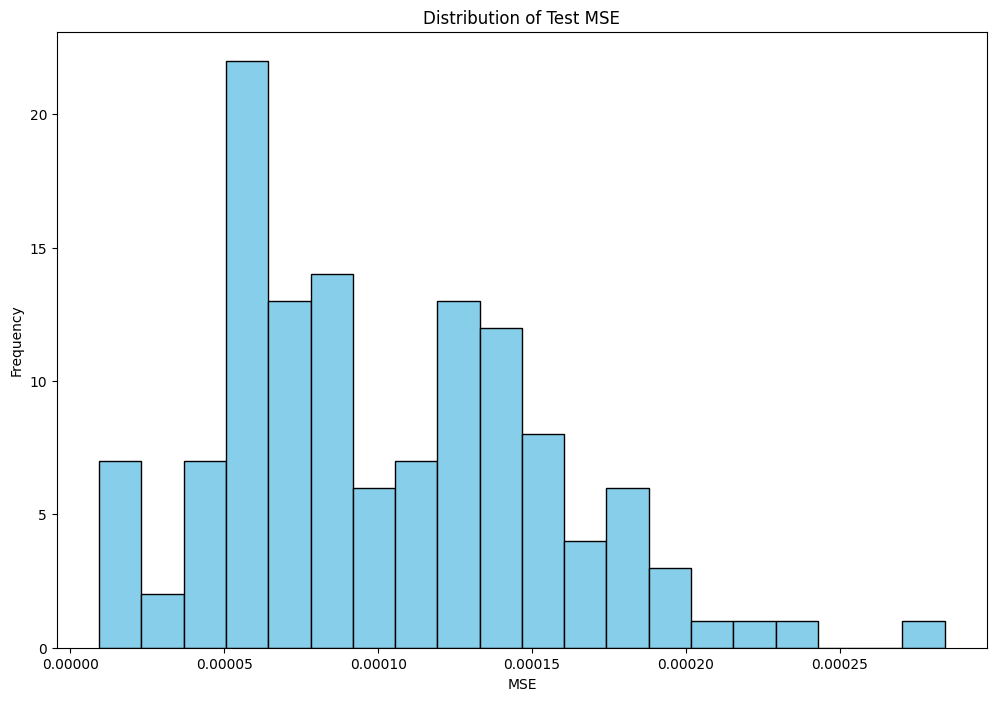

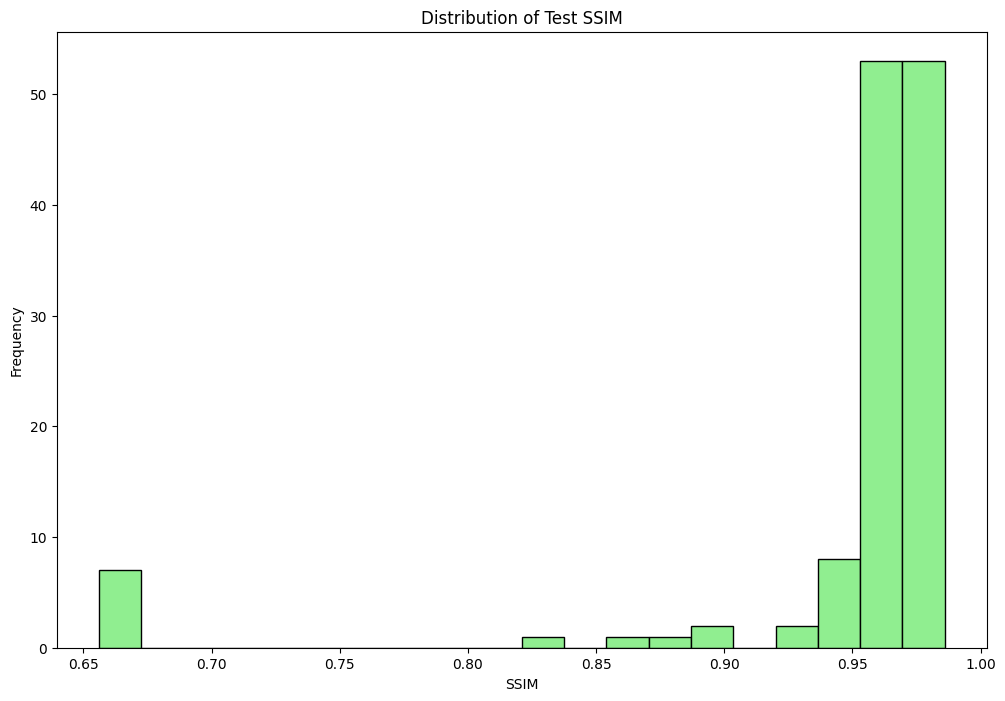

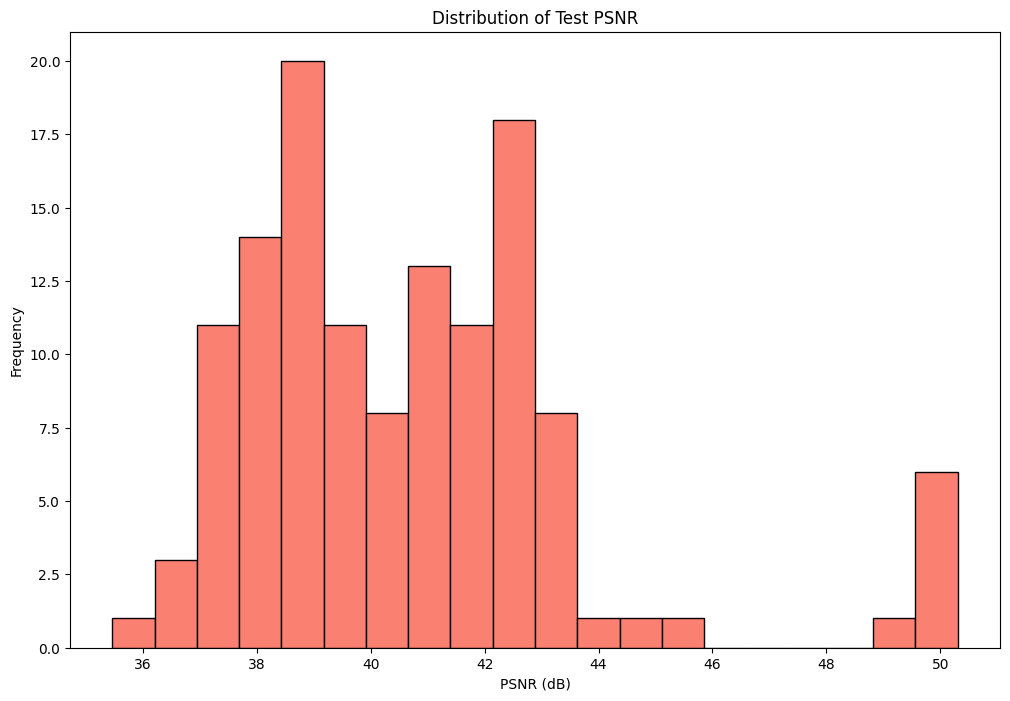

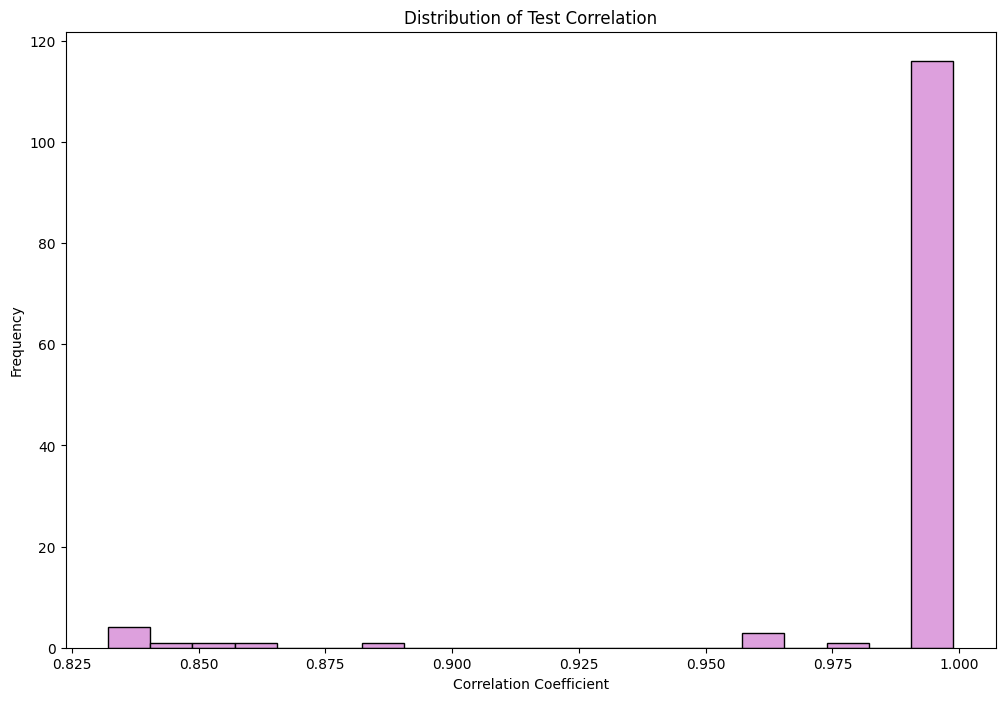

In [19]:
# Plot distribution of test MSE
plt.figure(figsize=(12, 8))
plt.hist(mse_test, bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Test MSE")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of test SSIM
plt.figure(figsize=(12, 8))
plt.hist(ssim_test, bins=20, color="lightgreen", edgecolor="black")
plt.title("Distribution of Test SSIM")
plt.xlabel("SSIM")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of test PSNR
plt.figure(figsize=(12, 8))
plt.hist(psnr_test, bins=20, color="salmon", edgecolor="black")
plt.title("Distribution of Test PSNR")
plt.xlabel("PSNR (dB)")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of test Correlation
plt.figure(figsize=(12, 8))
plt.hist(correlation_test, bins=20, color="plum", edgecolor="black")
plt.title("Distribution of Test Correlation")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Frequency")
plt.show()

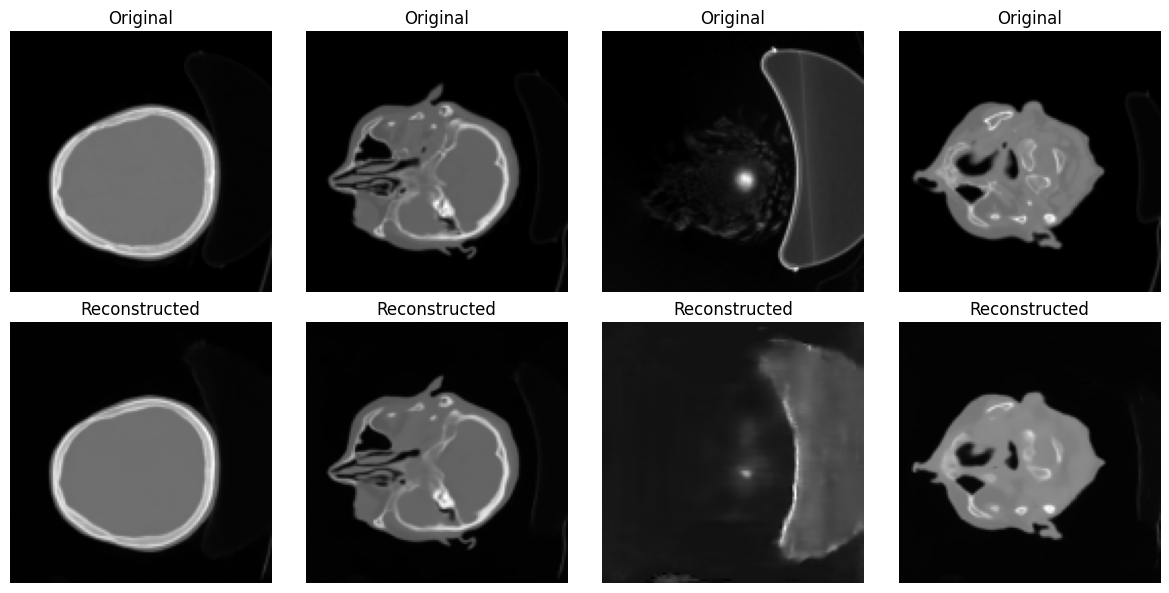

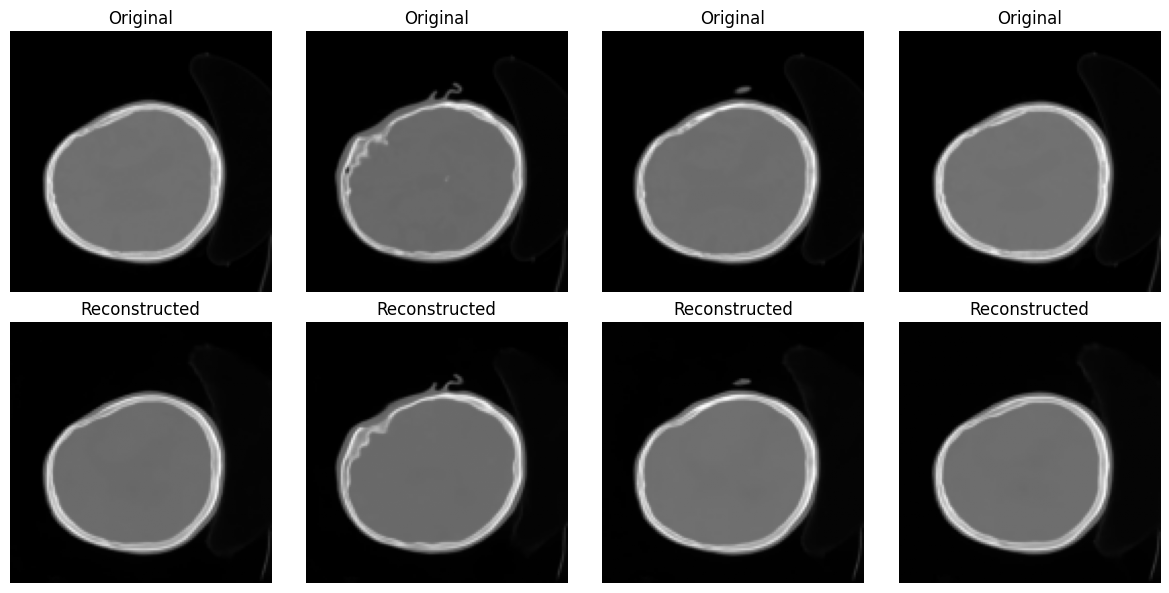

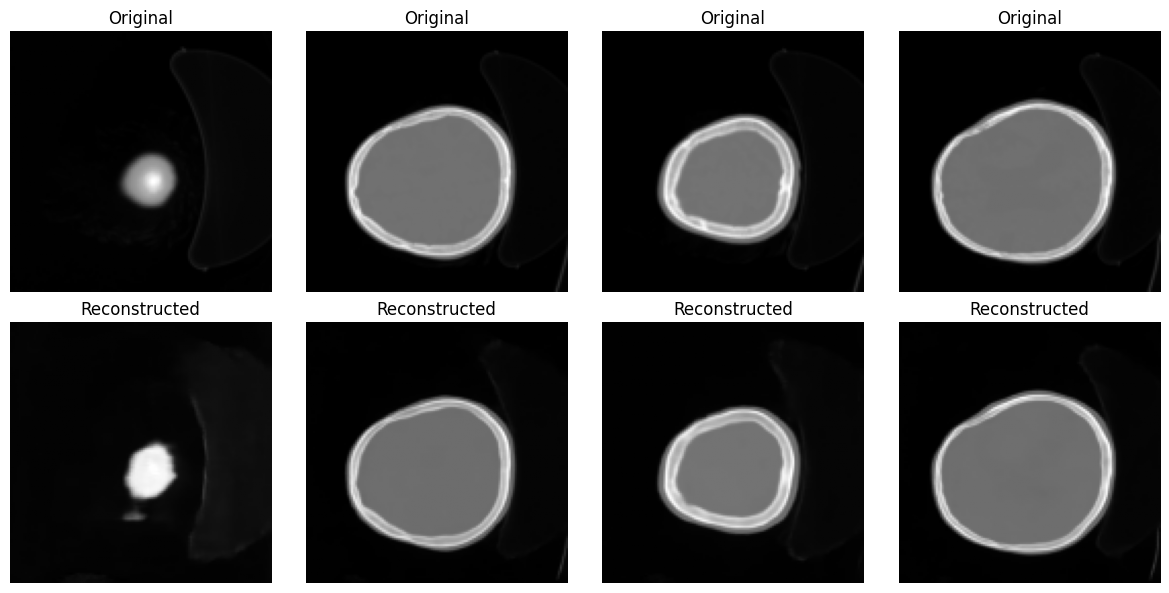

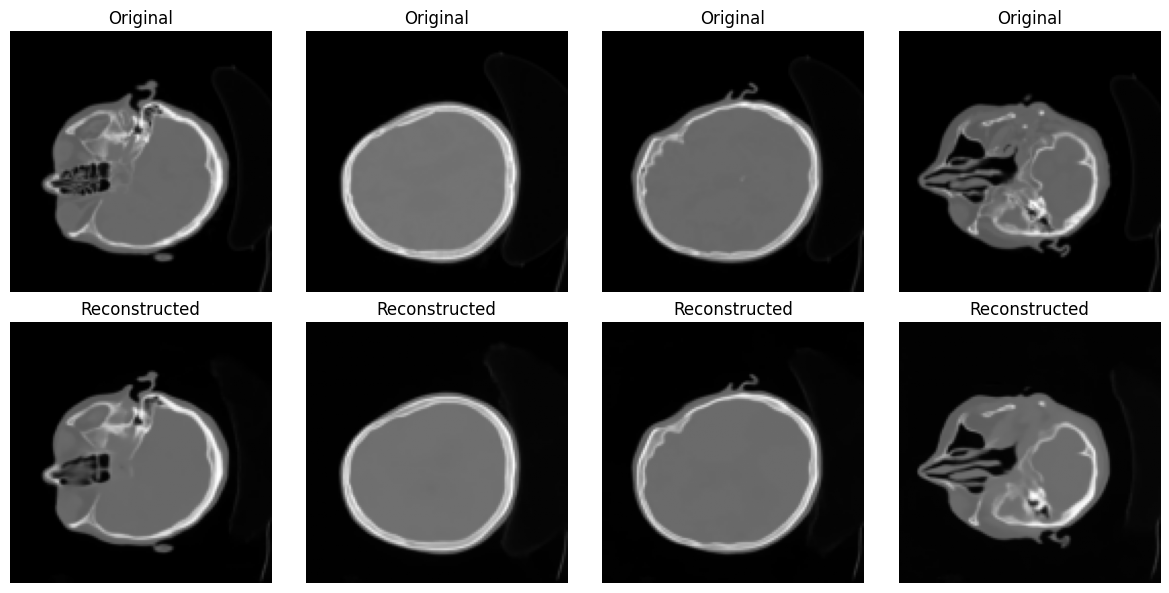

Average inference time per image: 2.31 milliseconds


In [12]:
import matplotlib.pyplot as plt
import time


def show_reconstructed_images(model, dataloader, device, num_images=5):
    model.eval()
    shown = 0
    inference_times = []
    with torch.no_grad():
        for sino, img in dataloader:
            sino = sino.unsqueeze(1).to(device, non_blocking=True)
            img = img.unsqueeze(1).to(device, non_blocking=True)

            start_time = time.time()
            output = model(sino)
            end_time = time.time()
            inference_times.append(end_time - start_time)

            batch_size = img.size(0)
            n = min(batch_size, num_images - shown)

            # Create a figure with 2 rows: original and reconstructed
            fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(3 * n, 6))

            for i in range(n):
                # Original image
                axes[0, i].imshow(img[i].cpu().numpy().squeeze(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")

                # Reconstructed image
                axes[1, i].imshow(output[i].cpu().numpy().squeeze(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")

            plt.tight_layout()
            plt.show()

            shown += n
            if shown >= num_images:
                break

    average_inference_time = sum(inference_times) / len(inference_times)
    print(
        f"Average inference time per image: {(1000 * average_inference_time / batch_size):.2f} milliseconds"
    )


show_reconstructed_images(generator, test_loader, device, num_images=16)

### Klasyczna rekonstrukcja - porównanie

In [13]:
# Image physical size in meters
MIN_PT = [-0.13, -0.13]
MAX_PT = [0.13, 0.13]

NUM_ANGLES = 256
RECO_IM_SHAPE = (128, 128)

IMPL = "astra_cuda"

In [14]:
import odl
from dival.reconstructors.odl_reconstructors import FBPReconstructor
from dival.util.plot import plot_images

test_pairs = dataset.get_data_pairs(part="test")

reco_space = odl.uniform_discr(
    min_pt=MIN_PT, max_pt=MAX_PT, shape=RECO_IM_SHAPE, dtype=np.float32
)
reco_geometry = odl.tomo.parallel_beam_geometry(reco_space, num_angles=NUM_ANGLES)
reco_ray_trafo = odl.tomo.RayTransform(reco_space, reco_geometry, impl=IMPL)

reconstructor = FBPReconstructor(reco_ray_trafo)

(array([<matplotlib.image.AxesImage object at 0x70d4f0674c50>,
        <matplotlib.image.AxesImage object at 0x70d4f0966840>], dtype=object),
 array([<Axes: >, <Axes: >], dtype=object))

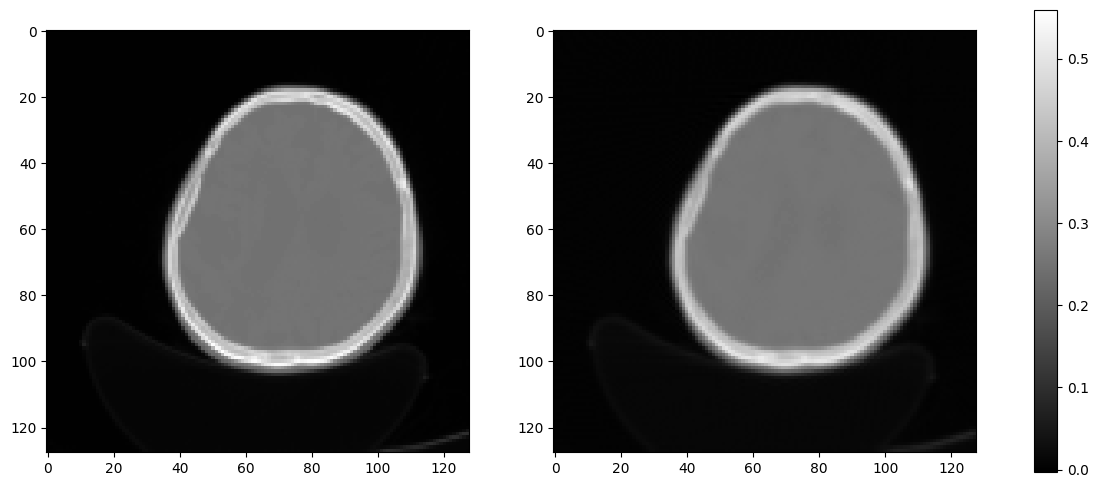

In [15]:
observation, ground_truth = test_pairs[0]

reconstruction = reconstructor.reconstruct(observation)

ground_truth = np.asarray(ground_truth)
reconstruction = np.asarray(reconstruction)

plot_images([ground_truth, reconstruction], fig_size=(15, 6), cbar="auto")

Maximum difference value: 0.060517


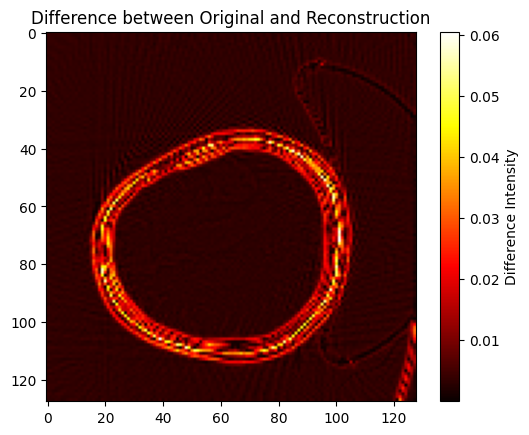

In [ ]:
# Compare original and reconstruction pixel by pixel

difference = np.abs(ground_truth - reconstruction)

print("Maximum difference value:", np.max(difference))

plt.imshow(difference, cmap='hot')
plt.title("Difference between Original and Reconstruction")
plt.colorbar(label='Difference Intensity')
plt.show()

In [ ]:
def calculate_psnr(img1, img2, max_val=1.0):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_val) - 10 * math.log10(mse)

In [ ]:
# Calculate average MSE, SSIM, and PSNR between ground truth and reconstruction

mse_sum = 0.0
ssim_sum = 0.0
psnr_sum = 0.0
correlation_sum = 0.0

for pair in test_pairs:
    observation, ground_truth = pair

    reconstruction = reconstructor.reconstruct(observation)

    ground_truth = np.asarray(ground_truth)
    reconstruction = np.asarray(reconstruction)

    mse_value = np.mean((ground_truth - reconstruction) ** 2)
    ssim_value = ssim(ground_truth, reconstruction, data_range=reconstruction.max() - reconstruction.min())
    if isinstance(ssim_value, (tuple, list)):
        ssim_value = ssim_value[0]
    psnr_value = calculate_psnr(ground_truth, reconstruction, max_val=1.0)
    correlation_value = np.corrcoef(ground_truth.flatten(), reconstruction.flatten())[0, 1]

    mse_sum += mse_value
    ssim_sum += float(ssim_value)
    psnr_sum += psnr_value
    correlation_sum += correlation_value

num_pairs = len(test_pairs)
avg_mse = mse_sum / num_pairs
avg_ssim = ssim_sum / num_pairs
avg_psnr = psnr_sum / num_pairs
avg_correlation = correlation_sum / num_pairs

print(f"Average MSE: {avg_mse:.6f}")
print(f"Average SSIM: {avg_ssim:.4f}")
print(f"Average PSNR: {avg_psnr:.2f}")
print(f"Average Correlation: {avg_correlation:.4f}")

Average MSE: 0.000076
Average SSIM: 0.8928
Average PSNR: 41.23
Average Correlation: 0.9981
